In [1]:
import hanoi
import numpy as np
from matplotlib import pyplot as plt

In [2]:
d_sample = hanoi.sample_data_1()

In [136]:
def fit_sigmoid(a, b, z):
    """
    Computes fitness based on a generaised logistic function.

    Arguments:
        a: 1D array-like of n specifying 
        b: 1D array-like of n
        z: (N, n) array representing n-dimensional phenotypes of N individuals.
    Returns: (N,) array representing fitness of N individuals
    """
    N = z.shape[0]
    n = z.shape[1]
    a = np.repeat(np.asarray(a)[None, :], N, axis = 0)
    b = np.repeat(np.asarray(b)[None, :], N, axis = 0)
    #return (1/(1 + np.exp(-b * (z - a)))**(1/n)).prod(axis = 1)
    return (1/(1 + np.exp((-b * (z - a)).sum(axis = 1))))

In [137]:

z_1D = np.linspace(-5, 5, 101).reshape([101,1])

In [138]:
z_1D.shape

(101, 1)

In [303]:
bs = np.array([0.25,  1, 4])

In [304]:
w_1D_s = np.array([fit_sigmoid(a = [1], b = [b], z = z_1D) for b in bs])

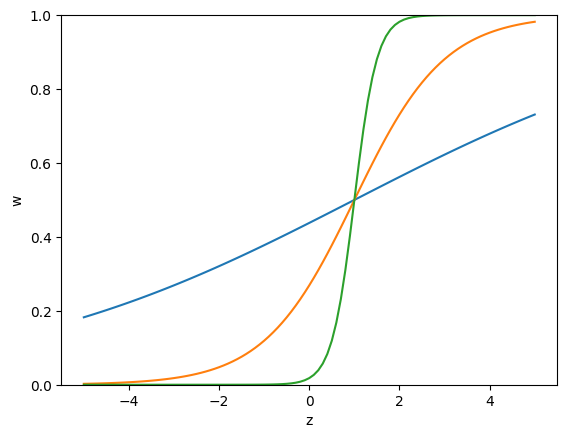

In [305]:
[plt.plot(z_1D, w_1D_s[i,:]) for i in range(len(bs))]
plt.xlabel("z")
plt.ylabel("w")
plt.ylim(0, 1)
plt.show()

$$w = \frac{1}{1 + e ^{{- \sum_\limits{i = 1}^{n}{b_i (z_i - a_i)}}}}$$

In [244]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-5,5,100), np.linspace(-5,5,100))

# Flatten to feed into fit_gaus
z_2D = np.column_stack([X.ravel(), Y.ravel()])

In [245]:
z_2D

array([[-5.       , -5.       ],
       [-4.8989899, -5.       ],
       [-4.7979798, -5.       ],
       ...,
       [ 4.7979798,  5.       ],
       [ 4.8989899,  5.       ],
       [ 5.       ,  5.       ]])

In [256]:
w_2D = fit_sigmoid(a = [-1,2], b = 3 * np.array([1/2, np.sqrt(3)/2]), z = z_2D)

In [257]:
w_2D

array([3.13272284e-11, 3.64522355e-11, 4.24156730e-11, ...,
       9.99999931e-01, 9.99999941e-01, 9.99999949e-01])

In [258]:
# Reshape to grid for pcolormesh
w_2D_grid = w_2D.reshape(100, 100)

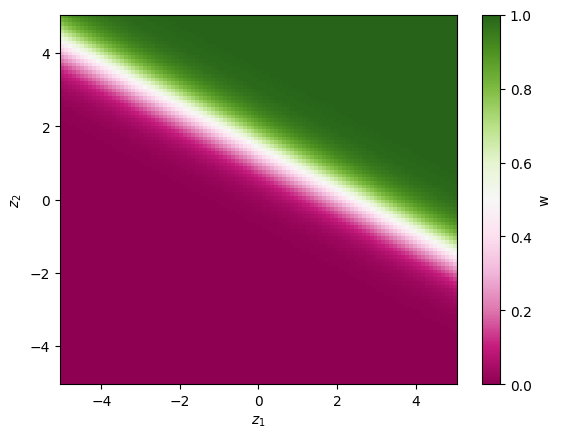

In [259]:
fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w_2D_grid, cmap='PiYG', vmin = 0, vmax = 1)
plt.colorbar(pcm, ax=ax, label='w')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()